# Importing The Libraries

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter #==> For Changing The Y axis format

# Loading The Dataset

In [43]:
df = pd.read_csv('/content/cleaned_omnichannel_retail_data.csv')
df.head(1).T

,0
Product ID,4277
Product Name,Refrigerator
Date,2024-01-03
Online Store Location,Mumbai
Sales Quantity,330
Selling Price,24.38
Promotions,No
Demand Trend,Increasing
Customer Segments,Regular
Warehouse Location,Chennai


Getting All The Columns

In [44]:
df.columns

Index(['Product ID', 'Product Name', 'Date', 'Online Store Location',
       'Sales Quantity', 'Selling Price', 'Promotions', 'Demand Trend',
       'Customer Segments', 'Warehouse Location', 'Stock Levels',
       'Stockout Frequency', 'Reorder Point', 'Order Fulfillment Time (days)',
       'Retail Store Location', 'Market Price', 'Competitor Prices',
       'Discounts', 'Sales Volume', 'Return Rate (%)', 'Elasticity Index',
       'Category_Electronics', 'Category_Fashion', 'Category_Furniture',
       'Category_Groceries', 'Category_Home Appliances'],
      dtype='object')

# Exploratory Data Analysis
1. Getting the info of our dataset

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12880 entries, 0 to 12879
Data columns (total 26 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Product ID                     12880 non-null  int64  
 1   Product Name                   12880 non-null  object 
 2   Date                           12880 non-null  object 
 3   Online Store Location          12880 non-null  object 
 4   Sales Quantity                 12880 non-null  int64  
 5   Selling Price                  12880 non-null  float64
 6   Promotions                     12880 non-null  object 
 7   Demand Trend                   12880 non-null  object 
 8   Customer Segments              12880 non-null  object 
 9   Warehouse Location             12880 non-null  object 
 10  Stock Levels                   12880 non-null  int64  
 11  Stockout Frequency             12880 non-null  int64  
 12  Reorder Point                  12880 non-null 

**Observations**
- As we are generally focusing on the building the dashboard, we don't really need the one hot encoded columns.
- We need to convert back into single one category column.

# 2. Converting The One Hot Encoded Columns Back Into The Single Column

In [46]:
category_cols = [
    'Category_Electronics',
    'Category_Fashion',
    'Category_Furniture',
    'Category_Groceries',
    'Category_Home Appliances'
]

df['Category'] = (
    df[category_cols].idxmax(axis=1).str.replace('Category_', '', regex=False)
)

**Dropping the One Hot Encoded Columns**

In [47]:
df.drop(columns = category_cols, inplace = True)

In [48]:
df.head().T

,0,1,2,3,4
Product ID,4277,5406,5617,5617,7315
Product Name,Refrigerator,Mixer,T-Shirt,T-Shirt,Jeans
Date,2024-01-03,2024-01-11,2024-04-04,2024-04-04,2024-11-25
Online Store Location,Mumbai,Kolkata,Ahmedabad,Ahmedabad,Chennai
Sales Quantity,330,429,298,298,336
Selling Price,24.38,10.22,13.41,13.41,59.54
Promotions,No,Yes,No,No,Yes
Demand Trend,Increasing,Decreasing,Stable,Stable,Stable
Customer Segments,Regular,Premium,Regular,Regular,Premium
Warehouse Location,Chennai,Kolkata,Pune,Delhi,Bangalore


# Finding The Return Rate By Category

Category
Electronics        10.244215
Fashion            10.131784
Groceries           9.961292
Furniture           9.923740
Home Appliances     9.547609
Name: Return Rate (%), dtype: float64


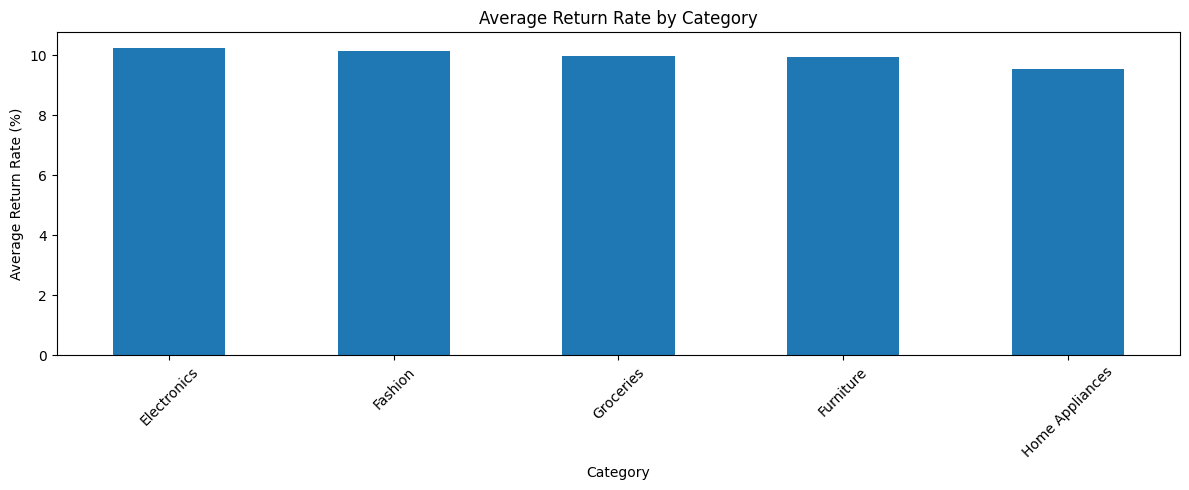

In [49]:
# Grouping The Columns Based On Category and Averge Return Rate
avgReturnRate = df.groupby('Category')['Return Rate (%)'].mean().sort_values(ascending = False)

print(avgReturnRate)

# Plotting The Data
plt.figure(figsize = (12,5))
avgReturnRate.plot(kind = 'bar')

plt.title('Average Return Rate by Category')
plt.xlabel('Category')
plt.ylabel('Average Return Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

**Observations**
- Most of the products in the different category having somewhat same average return rate.
- Still, **Home Appliances** products have **minimal return rate** as compared to other products in different categories

# Feature Engineering


# Creating KPIs for our Dashboard Building
1. Total Sales

In [50]:
df['Total Sales'] = df['Sales Quantity'] * df['Selling Price']
df.head(1).T

#Finding The Overall Revenue Generated by the company
totalRevenue = df['Total Sales'].sum()

print(f'Total Revenue:${totalRevenue}')

Total Revenue:$118124589.5


**Observations**
- I have created the Total Sales attribute and now we can use that in the dashboard for building the chart that shows the overall revenue that can be generated by the company by selling the products.

Plotting The Total Sales By Category

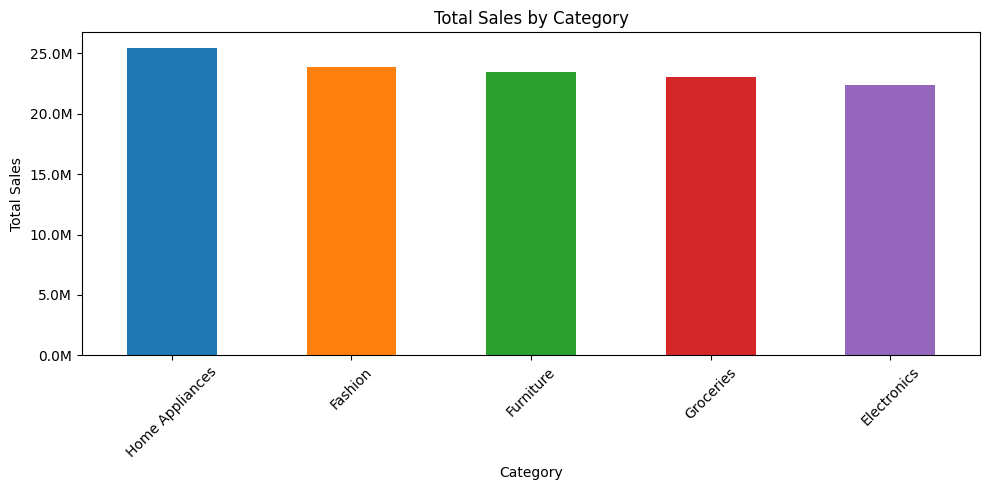

In [51]:
#Grouping The Total Sales and Category
salesByCategory = df.groupby('Category')['Total Sales'].sum().sort_values(ascending=False)
colors = ['#1F77B4', '#FF7F0E', '#2CA02C', '#D62728', '#9467BD']

plt.figure(figsize = (10,5))
salesByCategory.plot(kind = 'bar', color = colors)

# Convert to Millions
plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M')
)

plt.title('Total Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

# print(salesByCategory)

**Observations**
- From The Above, it is clear that the **Home Appliance** Category generate the highest revenue for the company.

# Finding The Top 5 Selling Product

In [52]:
highestSellingProducts = df.groupby('Product Name')['Total Sales'].sum().sort_values(ascending=False).head(5)

print(highestSellingProducts)

Product Name
Washing Machine    5661339.84
Fan                5626195.58
T-Shirt            5590333.04
Coffee             5531098.90
Desk               5462370.21
Name: Total Sales, dtype: float64


**Observations**
- From the above, it is cleared that the **Washing Machine** is the highest selling product for the company.

2. Total Units Sold

In [53]:
totalUnitsSold = df['Sales Quantity'].sum()

print(f'Total Units Sold:{totalUnitsSold}')

Total Units Sold:3231107


3. Inventory Recommendation

In [54]:
high_sales = df['Sales Quantity'].quantile(0.75)
low_sales = df['Sales Quantity'].quantile(0.25)

conditions = [
    (df['Sales Quantity'] >= high_sales) &
    (df['Stock Levels'] <= df['Reorder Point']),

    (df['Sales Quantity'] <= low_sales) &
    (df['Stock Levels'] > 2 * df['Reorder Point'])
]

choices = [
    'Increase Stock',
    'Reduce Stock'
]

df['Inventory Recommendation'] = np.select(
    conditions,
    choices,
    default='Maintain Stock'
)


In [55]:
df.tail().T

,12875,12876,12877,12878,12879
Product ID,6545,6545,6545,6281,4750
Product Name,Sofa,Sofa,Sofa,Jacket,Table
Date,2024-11-26,2024-11-26,2024-11-26,2024-02-15,2024-03-19
Online Store Location,Chennai,Chennai,Chennai,Kolkata,Ahmedabad
Sales Quantity,47,47,47,142,19
Selling Price,47.12,6.65,47.12,48.7,32.77
Promotions,No,No,No,No,Yes
Demand Trend,Decreasing,Decreasing,Decreasing,Decreasing,Decreasing
Customer Segments,Budget,Budget,Budget,Regular,Regular
Warehouse Location,Ahmedabad,Chennai,Chennai,Chennai,Kolkata


Determining the Date Range of the Dataset

In [56]:
print(df['Date'].min())
print(df['Date'].max())

2024-01-01
2024-12-30


**Observations**
- It is clear that I have one year sales data.
- So, I can create month-wise total sales KPI to know in which month the company generate the most of its revenue.

# Creating The Month-Wise Plot and KPI

In [57]:
# Finding The Month Name
df['Month'] = pd.to_datetime(df['Date']).dt.month_name()

In [58]:
df.head().T

,0,1,2,3,4
Product ID,4277,5406,5617,5617,7315
Product Name,Refrigerator,Mixer,T-Shirt,T-Shirt,Jeans
Date,2024-01-03,2024-01-11,2024-04-04,2024-04-04,2024-11-25
Online Store Location,Mumbai,Kolkata,Ahmedabad,Ahmedabad,Chennai
Sales Quantity,330,429,298,298,336
Selling Price,24.38,10.22,13.41,13.41,59.54
Promotions,No,Yes,No,No,Yes
Demand Trend,Increasing,Decreasing,Stable,Stable,Stable
Customer Segments,Regular,Premium,Regular,Regular,Premium
Warehouse Location,Chennai,Kolkata,Pune,Delhi,Bangalore


In [59]:
# Finding The Unique Months or Overall Months that's present in dataset
months = df['Month'].unique()
print(months)

['January' 'April' 'November' 'October' 'May' 'July' 'March' 'December'
 'August' 'September' 'February' 'June']


In [60]:
# Ordering The Months for proper analysis
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December']

monthly_sales = df.groupby('Month')['Total Sales'].sum().reindex(month_order).reset_index()
print(monthly_sales)


        Month  Total Sales
0     January   9796094.79
1    February   9068172.38
2       March  10295101.86
3       April   8590732.05
4         May   9968012.03
5        June  10051819.73
6        July   9988443.11
7      August  11124502.45
8   September   9534770.73
9     October  10797705.78
10   November   9706075.96
11   December   9203158.63


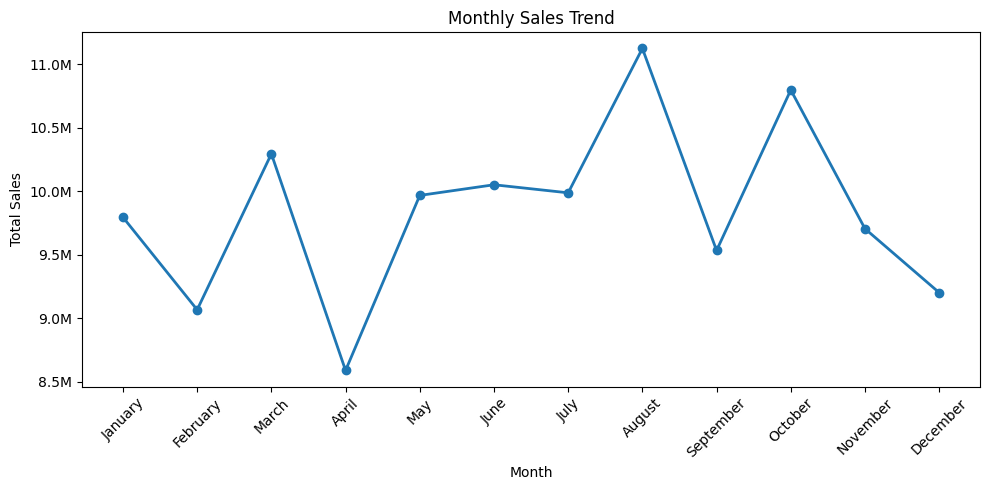

In [61]:
#Plotting The Data
plt.figure(figsize = (10,5))
plt.plot(
    monthly_sales['Month'],
    monthly_sales['Total Sales'],
    marker='o',
    linewidth=2
)

# Convert to Millions
plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M')
)

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

**Observations**
- From the above, it is cleared that in the month of **August** company generated **highest sales** of the products.
- While in the month of **April** company generated the **lowest sales** of the products.

4. Average Order Fulfillment Time

In [62]:
avgOrderFulfillmentTime = df['Order Fulfillment Time (days)'].mean()

print(f'Average Order Fulfillment Time:{avgOrderFulfillmentTime:.2f} Days')

Average Order Fulfillment Time:7.46 Days


**Observations**
- It is cleared that, on an average, it takes 7.46 days to fulfill the customer order.
- Needed to pay attention on it and try to lessen the average order fulfillment time to improve customer satisfaction.

# Evaluating the Impact of Promotions on Total Sales

In [63]:
promotionImpact = df.groupby('Promotions')['Total Sales'].mean().reset_index()

print(promotionImpact)


  Promotions  Total Sales
0         No  9227.983288
1        Yes  9117.350597


**Plotting The Impact of Promotions on Total Sales**

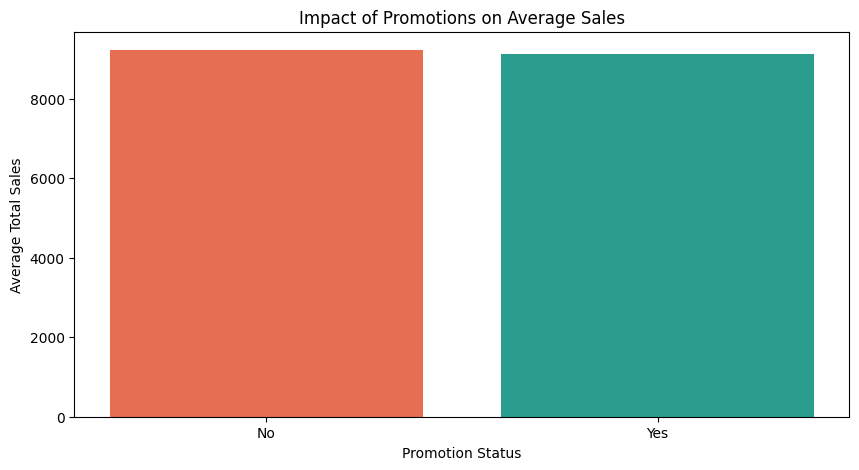

In [64]:
plt.figure(figsize=(10,5))

plt.bar(
    promotionImpact['Promotions'],
    promotionImpact['Total Sales'],
    color=['#E76F51', '#2A9D8F']
)

plt.title('Impact of Promotions on Average Sales')
plt.xlabel('Promotion Status')
plt.ylabel('Average Total Sales')

plt.show()

**Observations**
- As shown above,it indicates that promotions have a limited effect on total sales.
- Top-selling products appear to maintain strong sales performance even without significant promotional activities, suggesting that customer demand for these products is inherently high

# Analyzing The Impact of Customer Segment on the total sales

In [65]:
customerImpact = df.groupby('Customer Segments')['Total Sales'].mean().reset_index()

print(customerImpact)

  Customer Segments  Total Sales
0            Budget  9226.996668
1           Premium  9202.149198
2           Regular  9080.876970


**Plotting the impact of customer segments on the total sales**

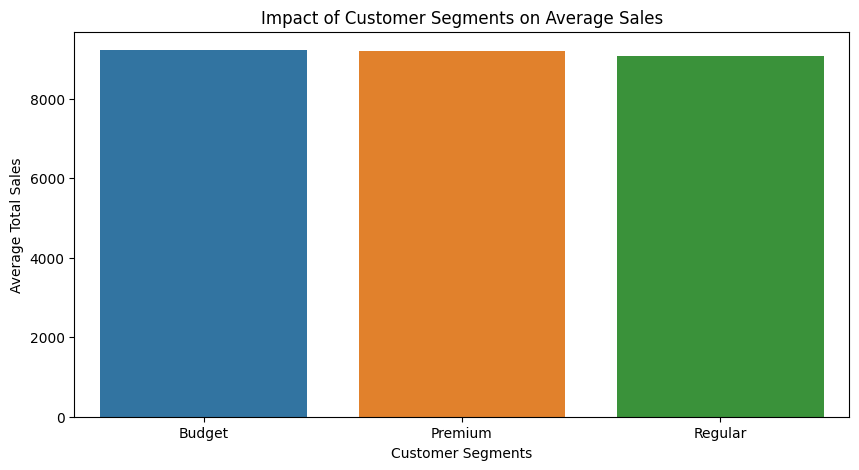

In [66]:
plt.figure(figsize = (10,5))

sns.barplot(
    data = customerImpact,
    x = 'Customer Segments',
    y = 'Total Sales',
    hue = 'Customer Segments'
)

plt.title('Impact of Customer Segments on Average Sales')
plt.xlabel('Customer Segments')
plt.ylabel('Average Total Sales')

plt.show()

**Observations**
- From the above analysis, it is cleared that our most valuable customer segment is **Budget** customer.
- However, the differences between the segments are minimal, indicating that customer segment has a limited influence on overall sales performance. This suggests that revenue is fairly balanced across different customer groups rather than being driven by a single segment.

# Using The Demand Trend To find the Top 5 Products with Increasing Demand

In [67]:
increasingDemandProducts = df[df['Demand Trend'] == 'Increasing'].groupby('Product Name')['Total Sales'].sum().sort_values(ascending = False).head()

print(increasingDemandProducts)

Product Name
Coffee             2374488.70
T-Shirt            2246386.95
Washing Machine    1912764.50
Sneakers           1875824.65
Jeans              1856030.88
Name: Total Sales, dtype: float64


**Observations**
- From the above analysis, we have found out the top 5 products with increasing demand.
- Using this analysis, company may plan for its inventory planning to ensure its stock availability for future case.

# Evaluating Inventory Distribution Across Warehouse Locations

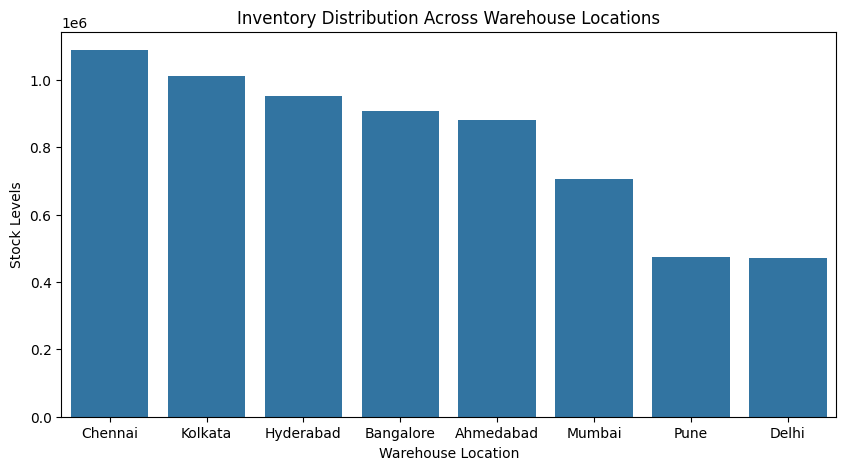

In [68]:
warehouseStock = df.groupby('Warehouse Location')['Stock Levels'].sum().sort_values(ascending = False).reset_index()

plt.figure(figsize = (10,5))

sns.barplot(data = warehouseStock, x = 'Warehouse Location', y = 'Stock Levels')
plt.title('Inventory Distribution Across Warehouse Locations')
plt.xlabel('Warehouse Location')
plt.ylabel('Stock Levels')

plt.show()

**Observations**
- Chennai holds the highest stock levels, followed by Kolkata and Hyderabad, indicating that these warehouses serve as major inventory hubs.
- In contrast, Pune and Delhi maintain the lowest stock levels, which may increase the risk of stock shortages if demand rises unexpectedly.
- The results suggest that inventory is concentrated in a few warehouses and may require redistribution to ensure balanced stock availability across locations

# Identify Warehouses with High Stockout Risk

Warehouse Location
Mumbai       9.928315
Chennai      9.430986
Delhi        9.422782
Hyderabad    9.422315
Kolkata      9.365639
Bangalore    9.362294
Ahmedabad    9.288375
Pune         9.281646
Name: Stockout Frequency, dtype: float64


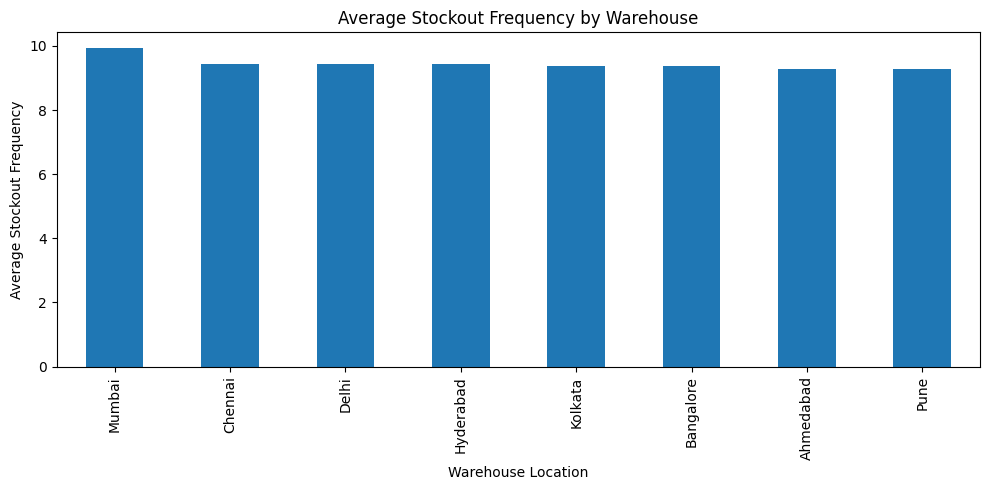

In [69]:

warehouse_stockout = (
    df.groupby('Warehouse Location')['Stockout Frequency']
      .mean()
      .sort_values(ascending=False)
)
print(warehouse_stockout)

plt.figure(figsize=(10,5))
warehouse_stockout.plot(kind='bar')

plt.title('Average Stockout Frequency by Warehouse')
plt.xlabel('Warehouse Location')
plt.ylabel('Average Stockout Frequency')

plt.tight_layout()
plt.show()

**Observations**
-  The analysis indicates that stockout frequency is relatively consistent across all warehouse locations.
- Mumbai records the highest average stockout frequency, while Pune records the lowest.
- However, the differences are minimal, suggesting that stockout risk is fairly evenly distributed across warehouses and no single location appears to be facing significantly higher inventory shortage issues.

# Dropping The Irrelevant Columns

In [70]:
cols = ['Product ID', 'Sales Volume', 'Elasticity Index']

df.drop(columns=cols, inplace=True)

In [71]:
df.head(1).T

,0
Product Name,Refrigerator
Date,2024-01-03
Online Store Location,Mumbai
Sales Quantity,330
Selling Price,24.38
Promotions,No
Demand Trend,Increasing
Customer Segments,Regular
Warehouse Location,Chennai
Stock Levels,10


# Converting The Final Dataset Into CSV

In [72]:
df.to_csv('final_omnichannel_dataset.csv')

# AUTHOR: MEHTA DHAIRYA